# Analysis & Visualization of screening data

## 1. Combining LFC & editing info (top variants)

- Extracting top variant for each guide for plotting purposes

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [92]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

def top_HGVSp_compiler(edit):
    """ 
    Input = HGVSp dataframe
    output = top HGVSp, Codon, & WT percentage
    """

    non_WT = edit[edit['HGVSp']!='WT']
    WT = edit[edit['HGVSp']=='WT'].rename(columns = {'%Reads':'WT_perc'})
    WT = WT[['gRNA_id', 'WT_perc']]

    top_per_group = non_WT.groupby('gRNA_id').apply(lambda x: x.nlargest(1, '%Reads'))
    top_per_group = top_per_group.reset_index(drop=True)
    new = pd.merge(top_per_group, WT, on='gRNA_id', how='outer')
    new['HGVSp'] = new['HGVSp'].fillna('WT')
    new = new.fillna(0)

    codon = []
    for i, val in new.iterrows():
        a = val['HGVSp']
        if a=='WT':
            codon.append(0)
        else:
            out = extract_numbers(a)
            codon.append(int(out))

    new['Codon'] = codon

    return new

In [200]:
samples = ['CBE_subpool1', 'ABE_subpool1', 'CBE_CDK12_13', 'ABE_CDK12_13']

e_holder = []
for sample in samples:
    edit = pd.read_csv(f'../../screening_data/04_editing/{sample}_HGVSp.zip')
    e1 = top_HGVSp_compiler(edit)
    e_holder.append(e1)

top_edit_dict = dict(zip(samples, e_holder))

# Subpool 1

In [259]:
def control_maker(targ_ABE, targ_CBE, name_CBE, name_ABE, WT_cutoff, plot_ABE, plot_CBE):

    if plot_ABE==True:

        non_edited_ABE = targ_ABE[targ_ABE['WT_perc']>=WT_cutoff]
        non_edited_ABE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

        intron_df_ABE = targ_ABE[targ_ABE['classification']=='intron']
        intron_df_ABE['Guide Class'] = 'Intron'
        nt_df_ABE = targ_ABE[targ_ABE['Gene']=='NT']
        nt_df_ABE['Guide Class'] = 'NT'

        controls_ABE = pd.concat((intron_df_ABE, nt_df_ABE, non_edited_ABE))

        controls_ABE['Editor']='ABE'
    #and CBE
    if plot_CBE==True:
        non_edited_CBE = targ_CBE[targ_CBE['WT_perc']>=WT_cutoff]
        non_edited_CBE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

        intron_df_CBE = targ_CBE[targ_CBE['classification']=='intron']
        intron_df_CBE['Guide Class'] = 'Intron'
        nt_df_CBE = targ_CBE[targ_CBE['Gene']=='NT']
        nt_df_CBE['Guide Class'] = 'NT'
        controls_CBE = pd.concat((intron_df_CBE, nt_df_CBE, non_edited_CBE))

        controls_CBE['Editor']='CBE'
    #-----merging the control dfs for simplicity of plotting-------
    if plot_CBE==plot_ABE: 
        #make names match up
        controls_ABE = controls_ABE.rename(columns = {name_ABE:name_CBE})
        controls_combined = pd.concat((controls_CBE, controls_ABE))

    else:
        if plot_CBE==True:
            controls_combined = controls_CBE
        if plot_ABE==True:
            controls_combined = controls_ABE

    return controls_combined

def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

In [ ]:
def subpool1_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True):


    genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

    #targ_CBE2 = targ_CBE_SY[(targ_CBE_SY['DMSO_median_CBE']>=min_DMSO_counts) & (targ_CBE_SY['Gene'].isin(genes)) & (targ_CBE_SY['WT_perc']<WT_cutoff)]
    targ_CBE2 = targ_CBE[(targ_CBE['base_RAW']>=min_base_counts) & (targ_CBE['Gene'].isin(genes))& (targ_CBE['WT_perc']<WT_cutoff)]
    targ_ABE2 = targ_ABE[(targ_ABE['base_RAW']>=min_base_counts) & (targ_ABE['Gene'].isin(genes))& (targ_ABE['WT_perc']<WT_cutoff)]



    name_CBE = f'LFC_median_{condition_of_interest_CBE}'
    FDR_CBE = f'FDR_{condition_of_interest_CBE}'
    name_ABE = f'LFC_median_{condition_of_interest_ABE}'
    FDR_ABE = f'FDR_{condition_of_interest_ABE}'


    genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
    ax_dict = {'CDK7':0, 'CDK8':1, 'CDK19':2, 'CDK9':3}

    fig, ax = plt.subplots(1,5, figsize=(15,5), sharey=True, width_ratios=[352, 472, 511, 379, 300])

    xticks = [[0,100,200,346],
            [0,100,200,300,400,464],
            [0,100,200,300,400,502],
            [0,100,200,300,372]]

    #-------plot CBE--------
    if plot_CBE == True:
        for i, gene in enumerate(genes):
            s = targ_CBE2[targ_CBE2['Gene']==gene]
            
            x = ax_dict[gene]

            #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
            #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

            bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
            bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_CBE], s = 20*-np.log10(bb1[FDR_CBE])+1, alpha=.2, color='tab:blue')
            ax[x].scatter(bb2['Codon'], bb2[name_CBE], s = 20*-np.log10(bb2[FDR_CBE])+1, alpha=1, color='tab:blue')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_CBE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

    #-----plot ABE-------
    if plot_ABE== True:
        for i, gene in enumerate(genes):
            s = targ_ABE2[targ_ABE2['Gene']==gene]
            
            x = ax_dict[gene]

            bb1 = s[(s[FDR_ABE]>FDR_cutoff) | ((s[name_ABE]<LFC_cutoff))]
            bb2 = s[(s[FDR_ABE]<=FDR_cutoff) & ((s[name_ABE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_ABE], s = 20*-np.log10(bb1[FDR_ABE])+1,alpha=.2, color='tab:purple')
            ax[x].scatter(bb2['Codon'], bb2[name_ABE], s = 20*-np.log10(bb2[FDR_ABE])+1, alpha=1, color='tab:purple')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)


            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_ABE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


    ax[0].axhline(0, color='black', linestyle='dashed')
    ax[1].axhline(0, color='black', linestyle='dashed')
    ax[2].axhline(0, color='black', linestyle='dashed')
    ax[3].axhline(0, color='black', linestyle='dashed')
    


    ax[0].set_title('CDK7', fontsize=15)
    ax[1].set_title('CDK8', fontsize=15)
    ax[2].set_title('CDK19', fontsize=15)
    ax[3].set_title('CDK9', fontsize=15)

    ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)


    #-----controls plotting--------
    controls_combined = control_maker(m_ABE, m_CBE, name_CBE, name_ABE, WT_cutoff, plot_ABE, plot_CBE)

    if plot_ABE == plot_CBE:
    #name_CBE2 = f'LFC_median_{condition_of_interest}'
        sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[4], hue='Editor',palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE'], alpha=.2, s=6, legend=False, dodge=True)
        sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[4],hue='Editor', palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE'],)

    else:
        if plot_ABE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[4], color='tab:purple', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[4], color='tab:purple')

        elif plot_CBE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[4], color='tab:blue', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[4], color='tab:blue')


    ax[4].axhline(0, color='black', linestyle='dashed')
    ax[4].spines[['right', 'top']].set_visible(False)
    ax[4].tick_params(axis='both', which='major', labelsize=13)
    ax[4].set_xlabel('')
    ax[4].set_title('Controls', fontsize=15)
    ax[4].legend(fontsize=10)

    fig.suptitle(f'{true_name} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & Base Mean Control Count ≥ {min_base_counts}', fontsize=14)

    #finally, add the KLIFS pocket annotations
    KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
    for j in list(ax_dict.keys()):
        print(j)
        numbers = list(KLIFS[j].dropna())
        r = find_ranges(numbers)
        a = ax_dict[j]
        for k in r:
            ax[a].axvspan(k[0],k[1], alpha=.2)

    return fig

In [250]:
numbers =list(KLIFS['CDK8'].dropna())

r = find_ranges(numbers)
r

[(25.0, 37.0),
 (49.0, 54.0),
 (62.0, 74.0),
 (76.0, 84.0),
 (94.0, 110.0),
 (141.0, 159.0),
 (171.0, 177.0)]

In [201]:
ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')


m_ABE = pd.merge(ABE, top_edit_dict['ABE_subpool1'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_ABE = m_ABE[(m_ABE['classification']=='targeting') & (~m_ABE['HGVSp'].isna())]

m_CBE = pd.merge(CBE,  top_edit_dict['CBE_subpool1'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_CBE = m_CBE[(m_CBE['classification']=='targeting') & (~m_CBE['HGVSp'].isna())]

CDK7
CDK8
CDK19
CDK9


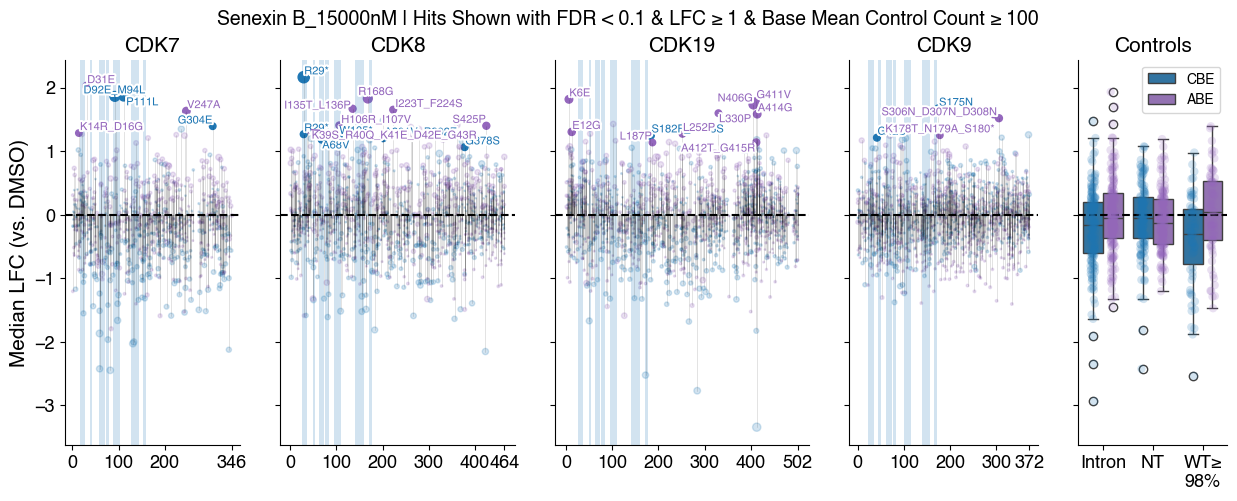

In [266]:
condition_of_interest_CBE = 'Senexin B_2000nM'
condition_of_interest_ABE = 'Senexin B_2000nM'
true_name = 'Senexin B_15000nM'
min_base_counts = 100
WT_cutoff = 98
FDR_cutoff = 0.1
LFC_cutoff = 1

fig1 = subpool1_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True)

# Subpool 2

In [275]:
def subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True):


    genes = ['CDK12', 'CDK13']

    #targ_CBE2 = targ_CBE_SY[(targ_CBE_SY['DMSO_median_CBE']>=min_DMSO_counts) & (targ_CBE_SY['Gene'].isin(genes)) & (targ_CBE_SY['WT_perc']<WT_cutoff)]
    targ_CBE2 = targ_CBE[(targ_CBE['base_RAW']>=min_base_counts) & (targ_CBE['Gene'].isin(genes))& (targ_CBE['WT_perc']<WT_cutoff)]
    targ_ABE2 = targ_ABE[(targ_ABE['base_RAW']>=min_base_counts) & (targ_ABE['Gene'].isin(genes))& (targ_ABE['WT_perc']<WT_cutoff)]


    name_CBE = f'LFC_median_{condition_of_interest_CBE}'
    FDR_CBE = f'FDR_{condition_of_interest_CBE}'
    name_ABE = f'LFC_median_{condition_of_interest_ABE}'
    FDR_ABE = f'FDR_{condition_of_interest_ABE}'


    genes = ['CDK12', 'CDK13']
    ax_dict = {'CDK12':0, 'CDK13':1,}

    fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True, width_ratios=[1490, 1512, 500])

    xticks = [[0,250,500,750,1000,1250,1490],
            [0,250,500,750,1000,1250,1512],]

    #-------plot CBE--------
    if plot_CBE == True:
        for i, gene in enumerate(genes):
            s = targ_CBE2[targ_CBE2['Gene']==gene]
            
            x = ax_dict[gene]

            #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
            #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

            bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
            bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_CBE], s = 20*-np.log10(bb1[FDR_CBE])+1, alpha=.2, color='tab:blue')
            ax[x].scatter(bb2['Codon'], bb2[name_CBE], s = 20*-np.log10(bb2[FDR_CBE])+1, alpha=1, color='tab:blue')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_CBE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

    #-----plot ABE-------
    if plot_ABE== True:
        for i, gene in enumerate(genes):
            s = targ_ABE2[targ_ABE2['Gene']==gene]
            
            x = ax_dict[gene]

            bb1 = s[(s[FDR_ABE]>FDR_cutoff) | ((s[name_ABE]<LFC_cutoff))]
            bb2 = s[(s[FDR_ABE]<=FDR_cutoff) & ((s[name_ABE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_ABE], s = 20*-np.log10(bb1[FDR_ABE])+1,alpha=.2, color='tab:purple')
            ax[x].scatter(bb2['Codon'], bb2[name_ABE], s = 20*-np.log10(bb2[FDR_ABE])+1, alpha=1, color='tab:purple')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)


            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_ABE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


    ax[0].axhline(0, color='black', linestyle='dashed')
    ax[1].axhline(0, color='black', linestyle='dashed')
   

    ax[0].set_title('CDK12', fontsize=15)
    ax[1].set_title('CDK13', fontsize=15)


    ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)


    #-----controls plotting--------
    controls_combined = control_maker(m_ABE, m_CBE, name_CBE, name_ABE, WT_cutoff, plot_ABE, plot_CBE)

    if plot_ABE == plot_CBE:
    #name_CBE2 = f'LFC_median_{condition_of_interest}'
        sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], hue='Editor',palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE'], alpha=.2, s=6, legend=False, dodge=True)
        sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2],hue='Editor', palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE'],)

    else:
        if plot_ABE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[2], color='tab:purple', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[2], color='tab:purple')

        elif plot_CBE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], color='tab:blue', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], color='tab:blue')


    ax[2].axhline(0, color='black', linestyle='dashed')
    ax[2].spines[['right', 'top']].set_visible(False)
    ax[2].tick_params(axis='both', which='major', labelsize=13)
    ax[2].set_xlabel('')
    ax[2].set_title('Controls', fontsize=15)
    ax[2].legend(fontsize=10)

    fig.suptitle(f'{true_name} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & Base Mean Control Count ≥ {min_base_counts}', fontsize=14)

    #finally, add the KLIFS pocket annotations
    KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
    for j in list(ax_dict.keys()):
        print(j)
        numbers = list(KLIFS[j].dropna())
        r = find_ranges(numbers)
        a = ax_dict[j]
        for k in r:
            ax[a].axvspan(k[0],k[1], alpha=.2)

    return fig

In [276]:
ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')


m_ABE = pd.merge(ABE, top_edit_dict['ABE_CDK12_13'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_ABE = m_ABE[(m_ABE['classification']=='targeting') & (~m_ABE['HGVSp'].isna())]

m_CBE = pd.merge(CBE,  top_edit_dict['CBE_CDK12_13'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_CBE = m_CBE[(m_CBE['classification']=='targeting') & (~m_CBE['HGVSp'].isna())]

In [ ]:

n = 'BSJ-4-116' #'CDK12-IN-2' 'HQ461'

CBE_name = f'CBE_{n}'
ABE_name = f'ABE_{n}'

CDK12
CDK13


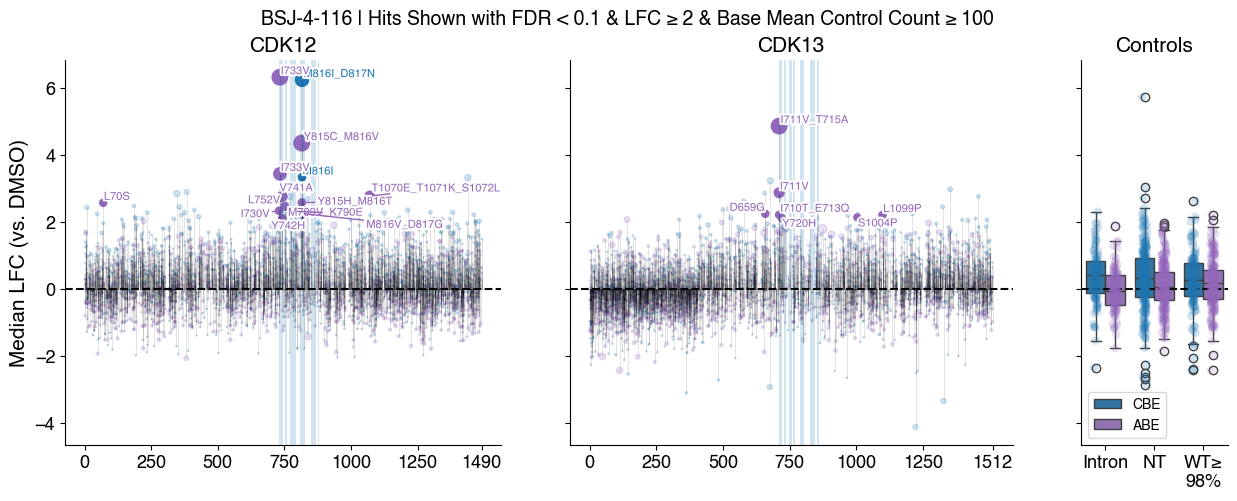

In [277]:

n = 'BSJ-4-116' #'CDK12-IN-2' 'HQ461'
true_name = n
condition_of_interest_CBE = f'CBE_{n}'
condition_of_interest_ABE = f'ABE_{n}'

min_base_counts = 100
WT_cutoff = 98
FDR_cutoff = 0.1
LFC_cutoff = 2

fig1 = subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True)

CDK12
CDK13


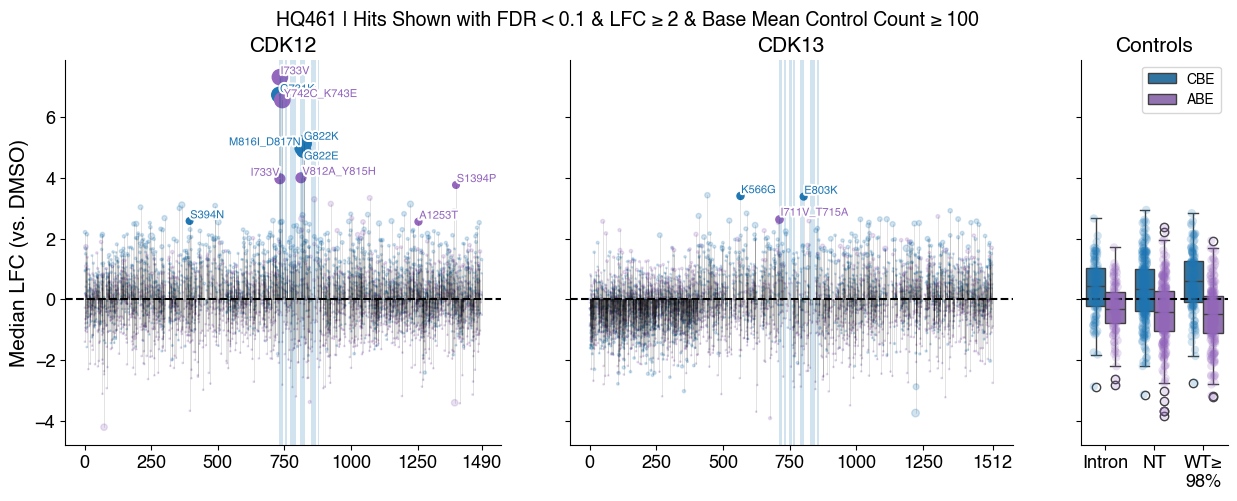

In [278]:
n = 'HQ461' #'CDK12-IN-2' 'HQ461'
true_name = n
condition_of_interest_CBE = f'CBE_{n}'
condition_of_interest_ABE = f'ABE_{n}'

min_base_counts = 100
WT_cutoff = 98
FDR_cutoff = 0.1
LFC_cutoff = 2

fig1 = subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True)

CDK12
CDK13


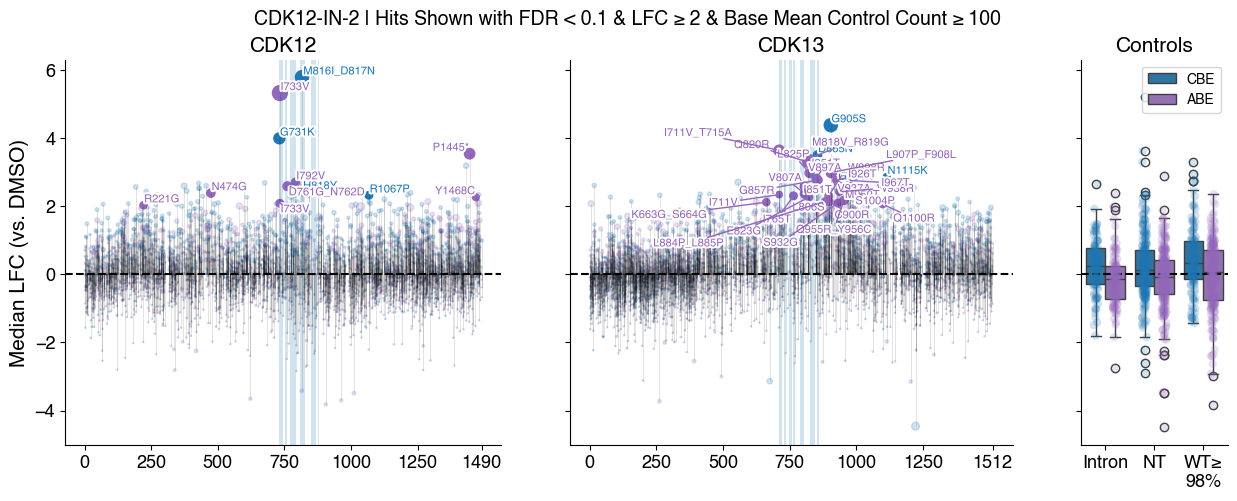

In [279]:
n = 'CDK12-IN-2' #'CDK12-IN-2' 'HQ461'
true_name = n
condition_of_interest_CBE = f'CBE_{n}'
condition_of_interest_ABE = f'ABE_{n}'

min_base_counts = 100
WT_cutoff = 98
FDR_cutoff = 0.1
LFC_cutoff = 2

fig1 = subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True)

# KLIFS fingerprints

- Generating heatmaps for clearer visualization of binding pocket hits for each drug
- Working from SAV dataframes (that include beyond top HGVSp)
- Can average across the different gRNAs targeting a codon

In [320]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
#KLIFS = KLIFS[KLIFS['KLIFS_idx']!='linker:50'].reset_index(drop=True)
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')

SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

In [445]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

ABE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

In [446]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

#first CBE
rg_CBE = []
for gene in genes:
    pocket = list(KLIFS[gene])

    relevant_guides = []
    for residue in pocket:
        subset = SAV_CBE1[(SAV_CBE1['Gene']==gene) & (SAV_CBE1['Codon']==residue) & (SAV_CBE1['%Reads']>=min_edit)]
        relevant_guides.append(list(subset['gRNA_id']))
    
    rg_CBE.append(relevant_guides)

#then ABE
rg_ABE = []
for gene in genes:
    pocket = list(KLIFS[gene])

    relevant_guides = []
    for residue in pocket:
        subset = SAV_ABE1[(SAV_ABE1['Gene']==gene) & (SAV_ABE1['Codon']==residue) & (SAV_ABE1['%Reads']>=min_edit)]
        relevant_guides.append(list(subset['gRNA_id']))
    
    rg_ABE.append(relevant_guides)

CBE_rg_dict = dict(zip(genes, rg_CBE))
ABE_rg_dict = dict(zip(genes, rg_ABE))

In [449]:
condition = 'KI-CDK9d-32N_5000nM'
min_base_counts = 100
min_edit = 20
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

KLIFS2 = KLIFS.copy()
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

for gene in genes:
    c = CBE_rg_dict[gene]
    a = ABE_rg_dict[gene]

    for i, val in KLIFS2.iterrows():
        nn = val[gene]
        subset_ABE = list(ABE_s1[ABE_s1['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
        subset_CBE = list(CBE_s1[CBE_s1['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

        comb1 = subset_ABE + subset_CBE

        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)


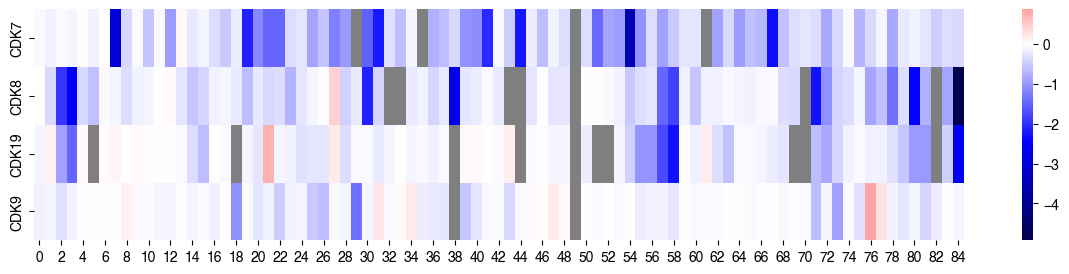

In [450]:
k2 = KLIFS2[['CDK7_guides', 'CDK7_avg', 'CDK8_guides', 'CDK8_avg', 'CDK19_guides',
       'CDK19_avg', 'CDK9_guides', 'CDK9_avg']]

for gene in genes:
    k2[gene] = k2[f'{gene}_avg']/k2[f'{gene}_guides']

plotting = k2[genes].T

fig, ax = plt.subplots(figsize=(15,3))
sns.heatmap(plotting, cmap='seismic', center=0, ax=ax)
ax.set_facecolor('tab:grey')

In [456]:
genes = ['CDK12', 'CDK13']
min_edit = 20
#first CBE
rg_CBE = []
for gene in genes:
    pocket = list(KLIFS[gene])

    relevant_guides = []
    for residue in pocket:
        subset = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['Codon']==residue) & (SAV_CBE2['%Reads']>=min_edit)]
        relevant_guides.append(list(subset['gRNA_id']))
    
    rg_CBE.append(relevant_guides)

#then ABE
rg_ABE = []
for gene in genes:
    pocket = list(KLIFS[gene])

    relevant_guides = []
    for residue in pocket:
        subset = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['Codon']==residue) & (SAV_ABE2['%Reads']>=min_edit)]
        relevant_guides.append(list(subset['gRNA_id']))
    
    rg_ABE.append(relevant_guides)

CBE_rg_dict = dict(zip(genes, rg_CBE))
ABE_rg_dict = dict(zip(genes, rg_ABE))

In [457]:
condition = 'HQ461'
min_base_counts = 100
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

KLIFS2 = KLIFS.copy()
genes = ['CDK12', 'CDK13']

for gene in genes:
    c = CBE_rg_dict[gene]
    a = ABE_rg_dict[gene]

    for i, val in KLIFS2.iterrows():
        nn = val[gene]
        subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
        subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

        comb1 = subset_ABE + subset_CBE

        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)

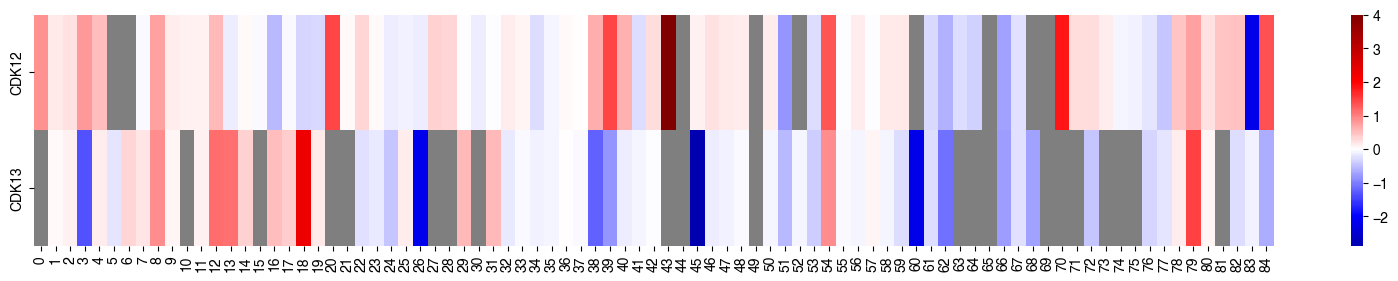

In [458]:
k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

for gene in genes:
    k2[gene] = k2[f'{gene}_avg']/k2[f'{gene}_guides']

plotting2 = k2[genes].T

fig, ax = plt.subplots(figsize=(20,3))
sns.heatmap(plotting2, cmap='seismic', center=0, ax=ax)
ax.set_facecolor('tab:grey')

In [459]:
condition = 'BSJ-4-116'
min_base_counts = 100
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

KLIFS2 = KLIFS.copy()
genes = ['CDK12', 'CDK13']

for gene in genes:
    c = CBE_rg_dict[gene]
    a = ABE_rg_dict[gene]

    for i, val in KLIFS2.iterrows():
        nn = val[gene]
        subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
        subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

        comb1 = subset_ABE + subset_CBE

        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
        KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)

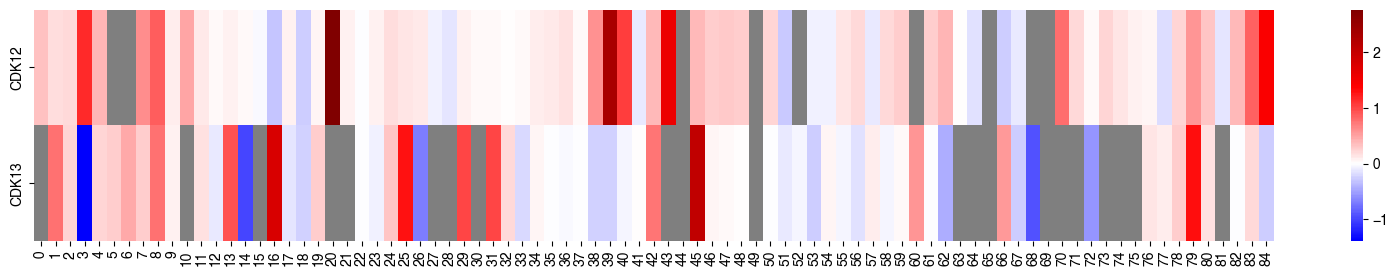

In [460]:
k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

for gene in genes:
    k2[gene] = k2[f'{gene}_avg']/k2[f'{gene}_guides']

plotting2 = k2[genes].T

fig, ax = plt.subplots(figsize=(20,3))
sns.heatmap(plotting2, cmap='seismic', center=0, ax=ax)
ax.set_facecolor('tab:grey')

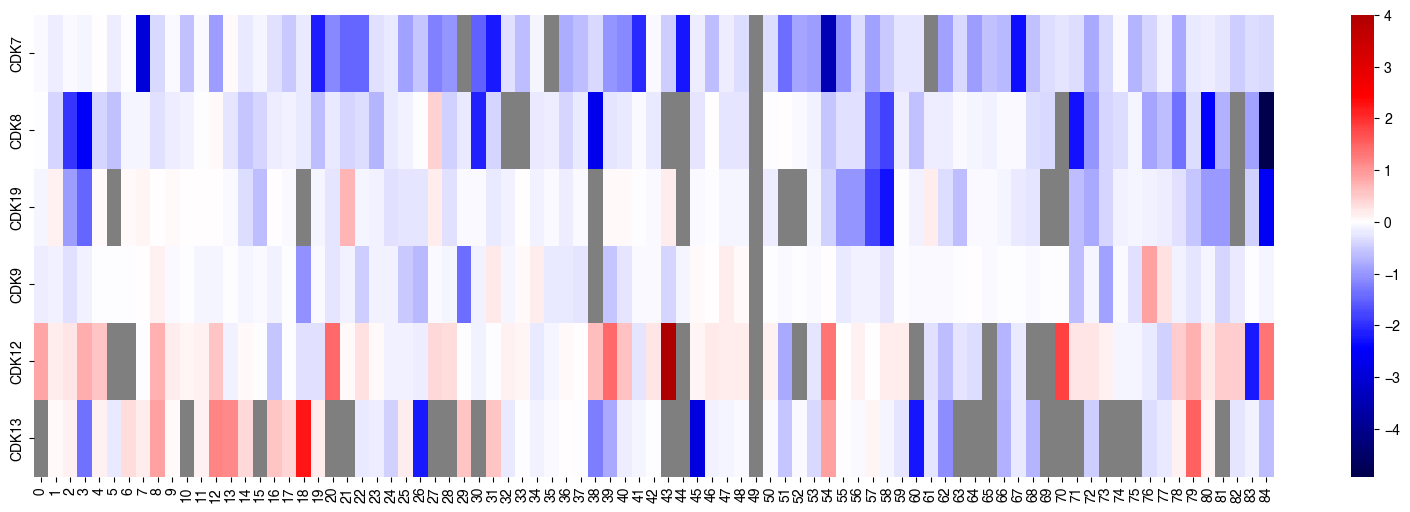

In [452]:
plotting3 = pd.concat((plotting, plotting2))

fig, ax = plt.subplots(figsize=(20,6))
sns.heatmap(plotting3, cmap='seismic', center=0, ax=ax)
ax.set_facecolor('tab:grey')

In [377]:
l1 = []
for k in rg:
    lengths = [len(i) for i in k]
    l1.append(lengths)

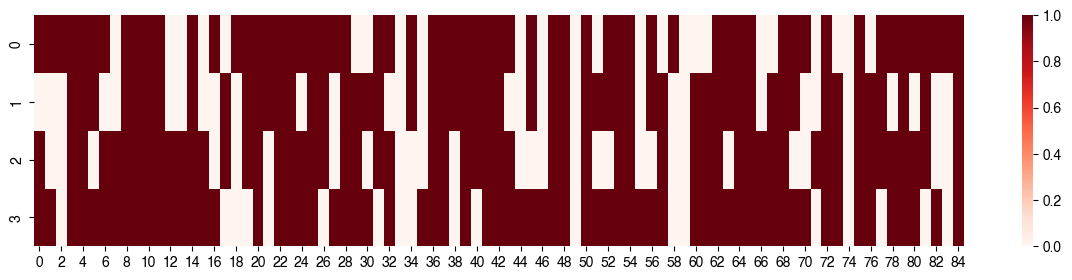

In [378]:
fig, ax = plt.subplots(figsize=(15,3))
sns.heatmap(l1, cmap='Reds', vmax=1, mask=(l1==0), ax=ax)
ax.set_facecolor('black')

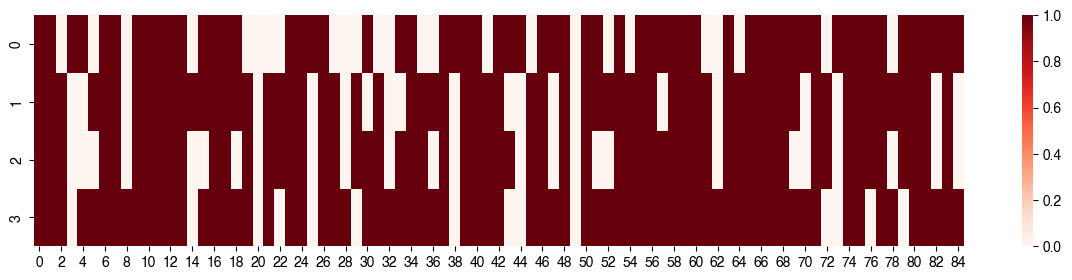

In [375]:
fig, ax = plt.subplots(figsize=(15,3))
sns.heatmap(l1, cmap='Reds', vmax=1, mask=(l1==0), ax=ax)
ax.set_facecolor('black')

In [374]:
pd.DataFrame(l1)

,0,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
0,6,3,0,1,6,0,6,2,0,4,...,2,2,3,0,2,2,3,1,3,1
1,2,4,1,0,0,1,3,5,0,2,...,8,2,2,1,1,1,2,0,2,0
2,1,3,1,0,0,0,3,5,0,6,...,7,1,4,0,1,2,2,0,1,0
3,1,3,3,0,6,3,9,4,2,4,...,1,0,6,2,0,5,4,1,4,1


In [321]:
cdk7 = list(KLIFS['CDK7'])
min_edit = 20

subset = SAV_ABE1[(SAV_ABE1['Codon'].isin(cdk7)) & (SAV_ABE1['%Reads']>=min_edit)]



In [334]:
SAV_ABE1

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene
0,Y502H,213320,98.464322,gRNA_CDK19_targ_6273,502,CDK19
1,A499T,1436,0.662829,gRNA_CDK19_targ_6273,499,CDK19
2,H500P,662,0.305566,gRNA_CDK19_targ_6273,500,CDK19
3,Q498R,503,0.232175,gRNA_CDK19_targ_6273,498,CDK19
4,Q498P,477,0.220174,gRNA_CDK19_targ_6273,498,CDK19
...,...,...,...,...,...,...
165359,R370V,1,0.000623,gRNA_CDK9_targ_1739,370,CDK9
165360,E367H,1,0.000623,gRNA_CDK9_targ_1739,367,CDK9
165361,E369Y,1,0.000623,gRNA_CDK9_targ_1739,369,CDK9
165362,F368E,1,0.000623,gRNA_CDK9_targ_1739,368,CDK9


<Axes: >

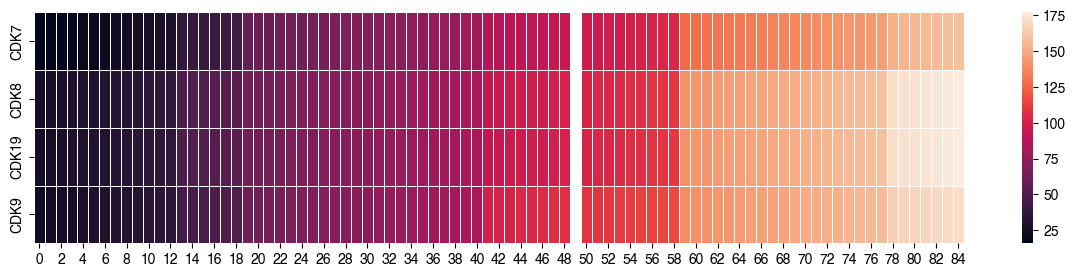

In [322]:
fig, ax = plt.subplots(figsize=(15,3))
sns.heatmap(KLIFS[['CDK7', 'CDK8', 'CDK19', 'CDK9']].T,linewidth=.5)

In [ ]:
aa = top_edit_dict['CBE_CDK12_13']
lfc = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

m1 = pd.merge(lfc, aa, on='gRNA_id', how='outer')

#exclude targeting variants with no sensor information!
t = m1[(m1['classification']=='targeting') & (~m1['HGVSp'].isna())]

In [186]:
condition = 'CBE_BSJ-4-116'
#condition = 'CBE_HQ461'
#condition = 'CBE_CDK12-IN-2'
m1[m1[f'FDR_{condition}']<.05]

,gRNA_id,Gene,classification,CBE_BSJ-4-116_REP1,CBE_BSJ-4-116_REP2,CBE_BSJ-4-116_REP3,LFC_avg_CBE_BSJ-4-116,LFC_median_CBE_BSJ-4-116,base_RPM,base_RAW,...,FDR_CBE_HQ461,p_CBE_T0,FDR_CBE_T0,p_Plasmid,FDR_Plasmid,HGVSp,#Reads,%Reads,WT_perc,Codon
1653,gRNA_CDK12_targ_3393,CDK12,targeting,2.411628,3.571029,3.344882,3.109180,3.344882,14.131250,431.0,...,0.719172,0.110616,0.635745,0.075892,0.376600,M816I,5773.0,33.960821,17.718689,816.0
1654,gRNA_CDK12_targ_3394,CDK12,targeting,5.339027,6.656715,6.255134,6.083625,6.255134,5.173406,139.0,...,0.000010,0.060805,0.501694,0.037796,0.297241,M816I_D817N,49660.0,73.092831,3.142432,816.0
4688,gRNA_nt_8995,NT,non-targeting control,1.944308,5.841834,5.741795,4.509312,5.741795,5.396718,145.0,...,0.458946,0.000138,0.085149,0.145385,0.600314,NaN,NaN,NaN,NaN,NaN


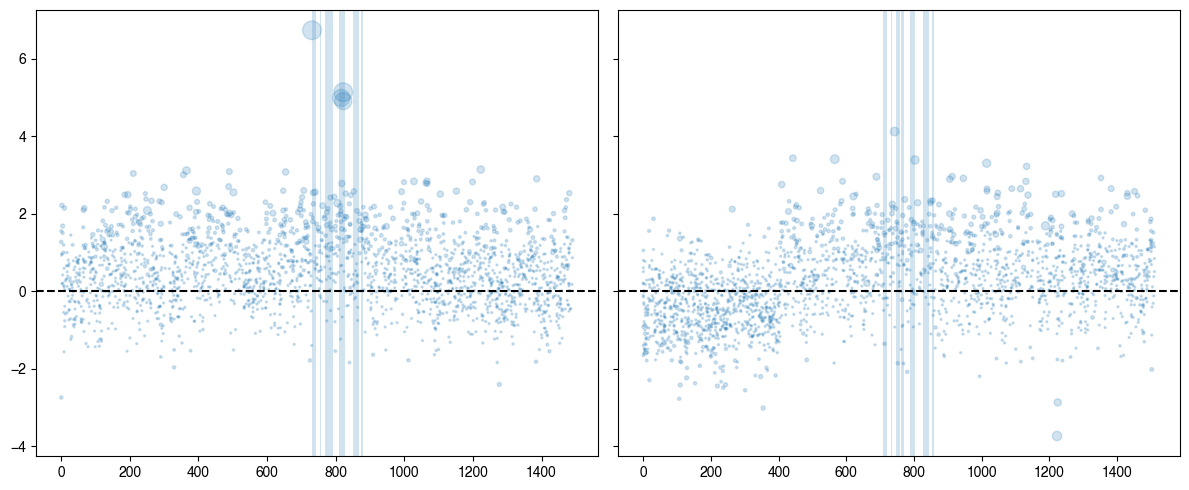

In [173]:
cdk12 = t[t['Gene']=='CDK12']
cdk13 = t[t['Gene']=='CDK13']

condition = 'CBE_BSJ-4-116'
condition = 'CBE_HQ461'
#condition = 'CBE_CDK12-IN-2'

#include filtration by RAW base mean
#also make it more modular

fig, ax = plt.subplots(1,2,figsize=(12,5), sharey=True)

ax[0].scatter(cdk12['Codon'], cdk12[f'LFC_median_{condition}'], s=30*-np.log10(cdk12[f'FDR_{condition}']) + 2, alpha=0.2)
ax[1].scatter(cdk13['Codon'], cdk13[f'LFC_median_{condition}'], s=30*-np.log10(cdk13[f'FDR_{condition}']) + 2, alpha=0.2)

ax[0].axhline(0, color='black', linestyle='dashed')
ax[1].axhline(0, color='black', linestyle='dashed')

my_list = list(KLIFS['CDK12'].dropna())
result_ranges = find_ranges(my_list)
for k in result_ranges:
    ax[0].axvspan(k[0],k[1], alpha=.2)


my_list = list(KLIFS['CDK13'].dropna())
result_ranges = find_ranges(my_list)
for k in result_ranges:
    ax[1].axvspan(k[0],k[1], alpha=.2)
fig.tight_layout()

In [166]:
def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

# Example usage:
my_list = list(KLIFS['CDK12'].dropna())
result_ranges = find_ranges(my_list)
print(result_ranges)

[(731.0, 743.0), (753.0, 758.0), (770.0, 782.0), (784.0, 792.0), (810.0, 826.0), (849.0, 867.0), (875.0, 881.0)]


In [187]:
aa = top_edit_dict['ABE_CDK12_13']
lfc = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')

m1 = pd.merge(lfc, aa, on='gRNA_id', how='outer')

#exclude targeting variants with no sensor information!
t = m1[(m1['classification']=='targeting') & (~m1['HGVSp'].isna())]

In [191]:
condition = 'ABE_BSJ-4-116'
condition = 'ABE_HQ461'
condition = 'ABE_CDK12-IN-2'
m1[m1[f'FDR_{condition}']<.01]

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,FDR_ABE_HQ461,p_ABE_T0,FDR_ABE_T0,p_Plasmid,FDR_Plasmid,HGVSp,#Reads,%Reads,WT_perc,Codon
492,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,9.985563e-07,0.001166,0.709679,0.487851,0.883638,I733V,950651.0,55.888593,0.392363,733.0
1010,gRNA_CDK12_targ_2750,CDK12,targeting,1.282848,0.118488,-2.579118,-0.392594,0.118488,10.649124,200.0,...,5.446645e-01,0.025979,0.986956,0.186581,0.826459,P1445*,6.0,0.862069,97.270115,1445.0
2864,gRNA_CDK13_targ_4604,CDK13,targeting,4.873180,4.681693,5.298524,4.951133,4.873180,96.766262,4449.0,...,4.557032e-02,0.121815,0.893562,0.417758,0.814436,I711V_T715A,274447.0,54.469873,0.606330,711.0
2935,gRNA_CDK13_targ_4675,CDK13,targeting,0.066350,1.116631,0.338507,0.507162,0.338507,26.009523,532.0,...,6.371203e-01,0.387249,0.893562,0.057494,0.535150,M818V_R819G,5152.0,30.968983,15.977398,818.0
2937,gRNA_CDK13_targ_4677,CDK13,targeting,-0.513254,0.375273,1.253420,0.371813,0.375273,14.681328,675.0,...,9.999971e-01,0.190459,0.970765,0.090891,0.582947,Q820R,7116.0,53.136201,11.813023,820.0
4108,gRNA_CDK13_targ_5848,CDK13,targeting,2.693251,1.634403,1.620919,1.982858,1.634403,8.360204,171.0,...,9.999971e-01,0.005045,0.944621,0.000100,0.005408,L907P_F908L,5421.0,34.429978,24.045729,907.0
4148,gRNA_CDK13_targ_5888,CDK13,targeting,0.538509,0.593926,1.228990,0.787142,0.593926,38.922549,758.0,...,7.987836e-01,0.080373,0.999936,0.040796,0.535150,I967T,3955.0,22.552318,73.444717,967.0
4177,gRNA_CDK13_targ_5917,CDK13,targeting,1.441546,2.289729,2.143422,1.958232,2.143422,12.619212,256.0,...,5.683865e-01,0.026490,0.996322,0.023098,0.515778,S1004P,6696.0,43.505945,44.233643,1004.0


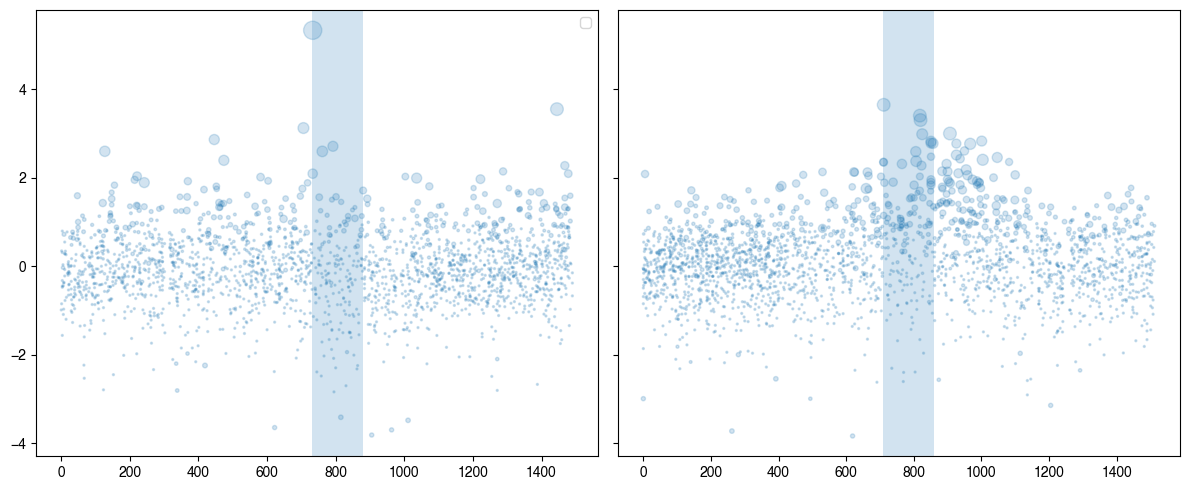

In [159]:
cdk12 = t[t['Gene']=='CDK12']
cdk13 = t[t['Gene']=='CDK13']

condition = 'ABE_BSJ-4-116'
condition = 'ABE_HQ461'
condition = 'ABE_CDK12-IN-2'

#include filtration by RAW base mean
#also make it more modular

fig, ax = plt.subplots(1,2,figsize=(12,5), sharey=True)

ax[0].scatter(cdk12['Codon'], cdk12[f'LFC_median_{condition}'], s=30*-np.log10(cdk12[f'FDR_{condition}']) + 2, alpha=0.2)
ax[1].scatter(cdk13['Codon'], cdk13[f'LFC_median_{condition}'], s=30*-np.log10(cdk13[f'FDR_{condition}']) + 2, alpha=0.2)
ax[0].legend()

ax[0].axvspan(min(list(KLIFS['CDK12'].dropna())), max(list(KLIFS['CDK12'].dropna())), alpha=.2)
ax[1].axvspan(min(list(KLIFS['CDK13'].dropna())), max(list(KLIFS['CDK13'].dropna())), alpha=.2)

fig.tight_layout()

In [156]:
list(KLIFS['CDK12'].dropna())

[731.0,
 732.0,
 733.0,
 734.0,
 735.0,
 736.0,
 737.0,
 738.0,
 739.0,
 740.0,
 741.0,
 742.0,
 743.0,
 753.0,
 754.0,
 755.0,
 756.0,
 757.0,
 758.0,
 770.0,
 771.0,
 772.0,
 773.0,
 774.0,
 775.0,
 776.0,
 777.0,
 778.0,
 779.0,
 780.0,
 781.0,
 782.0,
 784.0,
 785.0,
 786.0,
 787.0,
 788.0,
 789.0,
 790.0,
 791.0,
 792.0,
 810.0,
 811.0,
 812.0,
 813.0,
 814.0,
 815.0,
 816.0,
 817.0,
 818.0,
 819.0,
 820.0,
 821.0,
 822.0,
 823.0,
 824.0,
 825.0,
 826.0,
 849.0,
 850.0,
 851.0,
 852.0,
 853.0,
 854.0,
 855.0,
 856.0,
 857.0,
 858.0,
 859.0,
 860.0,
 861.0,
 862.0,
 863.0,
 864.0,
 865.0,
 866.0,
 867.0,
 875.0,
 876.0,
 877.0,
 878.0,
 879.0,
 880.0,
 881.0]

In [ ]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
list(KLIFS['CDK12'].dropna())

[731.0,
 732.0,
 733.0,
 734.0,
 735.0,
 736.0,
 737.0,
 738.0,
 739.0,
 740.0,
 741.0,
 742.0,
 743.0,
 753.0,
 754.0,
 755.0,
 756.0,
 757.0,
 758.0,
 770.0,
 771.0,
 772.0,
 773.0,
 774.0,
 775.0,
 776.0,
 777.0,
 778.0,
 779.0,
 780.0,
 781.0,
 782.0,
 784.0,
 785.0,
 786.0,
 787.0,
 788.0,
 789.0,
 790.0,
 791.0,
 792.0,
 810.0,
 811.0,
 812.0,
 813.0,
 814.0,
 815.0,
 816.0,
 817.0,
 818.0,
 819.0,
 820.0,
 821.0,
 822.0,
 823.0,
 824.0,
 825.0,
 826.0,
 849.0,
 850.0,
 851.0,
 852.0,
 853.0,
 854.0,
 855.0,
 856.0,
 857.0,
 858.0,
 859.0,
 860.0,
 861.0,
 862.0,
 863.0,
 864.0,
 865.0,
 866.0,
 867.0,
 875.0,
 876.0,
 877.0,
 878.0,
 879.0,
 880.0,
 881.0]

In [24]:
fp = '../../screening_data/04_editing/ABE_CDK12_13/HGVSp_only'
f = os.listdir(fp)
for i in f:
    if 'csv' in i:
        a = pd.read_csv(f'{fp}/{i}')
        print(i)
        print(len(np.unique(a['gRNA_id'])))

ABE_CDK12-IN-2_HGVSp.csv
4474
ABE_HQ461_HGVSp.csv
4457
ABE_BSJ-4-116_HGVSp.csv
4496
ABE_T0_HGVSp.csv
4484
ABE_DMSO_HGVSp.csv
4480


In [12]:
orig = pd.read_csv('../../screening_data/CBE_subpool_1_screen_data/editing/all_samples_combined_HGVSp_only.zip')
orig

,gRNA_id,HGVSp,#Reads,%Reads
0,gRNA_CDK7_targ_1,A2V,131422,55.961404
1,gRNA_CDK7_targ_1,WT,61954,26.380917
2,gRNA_CDK7_targ_1,A2G,9080,3.866396
3,gRNA_CDK7_targ_1,L3V,3152,1.342168
4,gRNA_CDK7_targ_1,M1D_A2G_L3S_D4G_V5R_K6E,2478,1.055169
...,...,...,...,...
767221,gRNA_CDK19_targ_6972,Y3*_F5L,1,0.001126
767222,gRNA_CDK19_targ_6972,Y3D,1,0.001126
767223,gRNA_CDK19_targ_6972,Y3N_D4*,1,0.001126
767224,gRNA_CDK19_targ_6972,Y3N_D4E,1,0.001126


In [32]:
edit

,gRNA_id,HGVSp,#Reads,%Reads
0,gRNA_CDK19_targ_6273,WT,103660,92.023614
1,gRNA_CDK19_targ_6273,R501Q,3224,2.862089
2,gRNA_CDK19_targ_6273,Q498L_A499T_H500R_R501P_Y502T,1137,1.009366
3,gRNA_CDK19_targ_6273,Y502H,1027,0.911714
4,gRNA_CDK19_targ_6273,H500P,547,0.485596
...,...,...,...,...
792246,gRNA_CDK9_targ_1739,R370N_F372L,1,0.000406
792247,gRNA_CDK9_targ_1739,R370P_V371F,1,0.000406
792248,gRNA_CDK9_targ_1739,R370Q_V371F,1,0.000406
792249,gRNA_CDK9_targ_1739,V371L_F372I,1,0.000406


In [33]:
len(np.unique(orig['gRNA_id']))

2439

In [18]:
a1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1/HGVSp_only/KB-0742_1500nM_HGVSp.csv')

len(np.unique(a1['gRNA_id']))

2437